# A first real analysis with scFair

The other tutorial ({doc}`pbmc10k_hvg_compare`) is a **method comparison** —
it needs gold cell-type labels and measures scFair against plain scanpy HVG.
This notebook is different: a **first analysis** on unlabeled counts, the way
most people start after sequencing.

## What scFair is for (two problems)

1. **How many genes (`n`)?** Default `n_top_genes="auto"` suggests a base list
   size from the data. It is a **safe default and a prompt**, not a claim that
   this `n` is always optimal. Pass `n_top_genes=2000` for a fixed paper protocol.
2. **Unfair HVG allocation.** Global top-`k` lists are filled by large populations;
   markers for smaller types often sit just below the cutoff. Default
   `balance_method="append"` freezes that global ranking and **appends** a short
   tail of near-miss genes so those slots are less often lost.

## Pipeline note (current scanpy style)

After HVG, **do not** subset with `adata = adata[:, adata.var["highly_variable"]]`.
Keep the full matrix. `sc.tl.pca` uses `mask_var="highly_variable"` by default
when that column is present.

Steps: load counts → light QC → `scfair.pp.highly_variable_genes` → the usual
PCA / neighbors / Leiden / UMAP path.


In [1]:
import tempfile
import warnings
from pathlib import Path

import scanpy as sc

import scfair as scf

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)
# Send the auto-downloaded dataset to a system temp dir, not a "data/" folder
# next to this notebook -- keeps the repo / docs tree free of downloaded data.
sc.settings.datasetdir = Path(tempfile.gettempdir()) / "scanpy_data"

print("scanpy", sc.__version__, "| scfair", scf.__version__)


scanpy 1.12.3 | scfair 0.7.0


## 1. Load raw counts

`sc.datasets.pbmc3k()` fetches 2,700 PBMCs with raw UMI counts and no cell-type
labels — a stand-in for "a matrix you just got off the sequencer". No file
placement is needed; it downloads to a local cache the first time you run this.


In [2]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
adata


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

## 2. Light QC

Nothing scFair-specific here — the same filtering you would do before any HVG
call: drop very low-count cells, drop genes seen in almost no cells, drop
likely doublets / dying cells by gene count and mitochondrial fraction.
scFair expects **raw integer counts** in `.X` (or a counts layer), so QC
filtering (which does not touch the values) is fine to do first; normalization
is not.


In [3]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
adata = adata[adata.obs["n_genes_by_counts"] < 4000].copy()

adata.shape


(2698, 13714)

## 3. Run scFair

One call with product defaults: **auto `n` + append**.

- **Problem A (list size):** structure-aware auto picks a base `k` (often near
  2000; low density confidence prefers 2000 over a risky short list).
- **Problem B (allocation):** append adds near-miss genes from the **same**
  ranking; the base top-`k` is never displaced.

Auto is multi-seed and **slower** than a single scanpy HVG pass. For a fixed
budget, use `n_top_genes=2000`. There is still no intermediate clustering on
the default `append` path after `k` is chosen.


In [4]:
scf.pp.highly_variable_genes(adata)

print(int(adata.var["highly_variable"].sum()), "genes selected")

# scfair_score is an unbounded per-flavor variability statistic (seurat_v3
# variances_norm here), not a 0-1 probability — most genes cluster near 1.0,
# so only the ranking (sorted order) is meaningful, not the raw number.
# Sorting by it shows the genes actually driving the selection:
adata.var[["highly_variable", "highly_variable_rank", "scfair_score"]] \
    .sort_values("scfair_score", ascending=False).head()


2200 genes selected


,highly_variable,highly_variable_rank,scfair_score
index,,,
PPBP,True,0.0,11.172256
S100A9,True,1.0,7.993364
LYZ,True,2.0,7.972817
IGLL5,True,3.0,7.964822
GNLY,True,4.0,7.493396


### What the call recorded

`adata.uns["scfair"]["hvg"]` holds the full record: which options were used,
how large the final list is, and (with `diagnose=True`, the default) advisory
tips about whether this dataset looks like one where balancing matters.


In [5]:
h = adata.uns["scfair"]["hvg"]
print("final list size:", h["n_highly_variable_final"])
print("method:", h["balance_method"])
print()
print("diagnosis recommendation:", h["diagnosis"]["recommendation"])
for tip in h["diagnosis"]["tips"]:
    print("-", tip)


final list size: 2200
method: append

diagnosis recommendation: keep_current


On the default `"append"` path there is no intermediate clustering, so the diagnosis is mostly descriptive here: `recommendation="keep_current"` and an empty `tips` list, because nothing was measured that would flag a problem. The imbalance metrics (`max_frac`, cluster sizes, ...) are dead fields on the current product surface: `append` and `none` never build an intermediate clustering, so they stay unpopulated. They only ever populated for the cluster-aware `hybrid`/`score`/`reweight` balance methods, which were removed from the public API (passing them now raises `ValueError`). See {doc}`../faq` for what each field means.


## 4. Continue the usual pipeline

Normalize and log-transform, then PCA.

**Do not subset** to the HVG list. Current scanpy tutorials keep all genes;
`sc.tl.pca` restricts itself to `adata.var["highly_variable"]` by default
(`mask_var="highly_variable"`) when that column is present. That is enough for
the usual neighbors → Leiden → UMAP path — no older
`adata.raw = adata` / `adata = adata[:, highly_variable]` step is required.


In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.tl.pca(adata, svd_solver="arpack", random_state=0)  # uses the HVG mask automatically
sc.pp.neighbors(adata, random_state=0)
sc.tl.leiden(adata, random_state=0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata, random_state=0)

adata.obs["leiden"].value_counts()


leiden
2    586
6    538
0    358
7    350
1    347
5    160
4    155
3    141
8     51
9     12
Name: count, dtype: int64

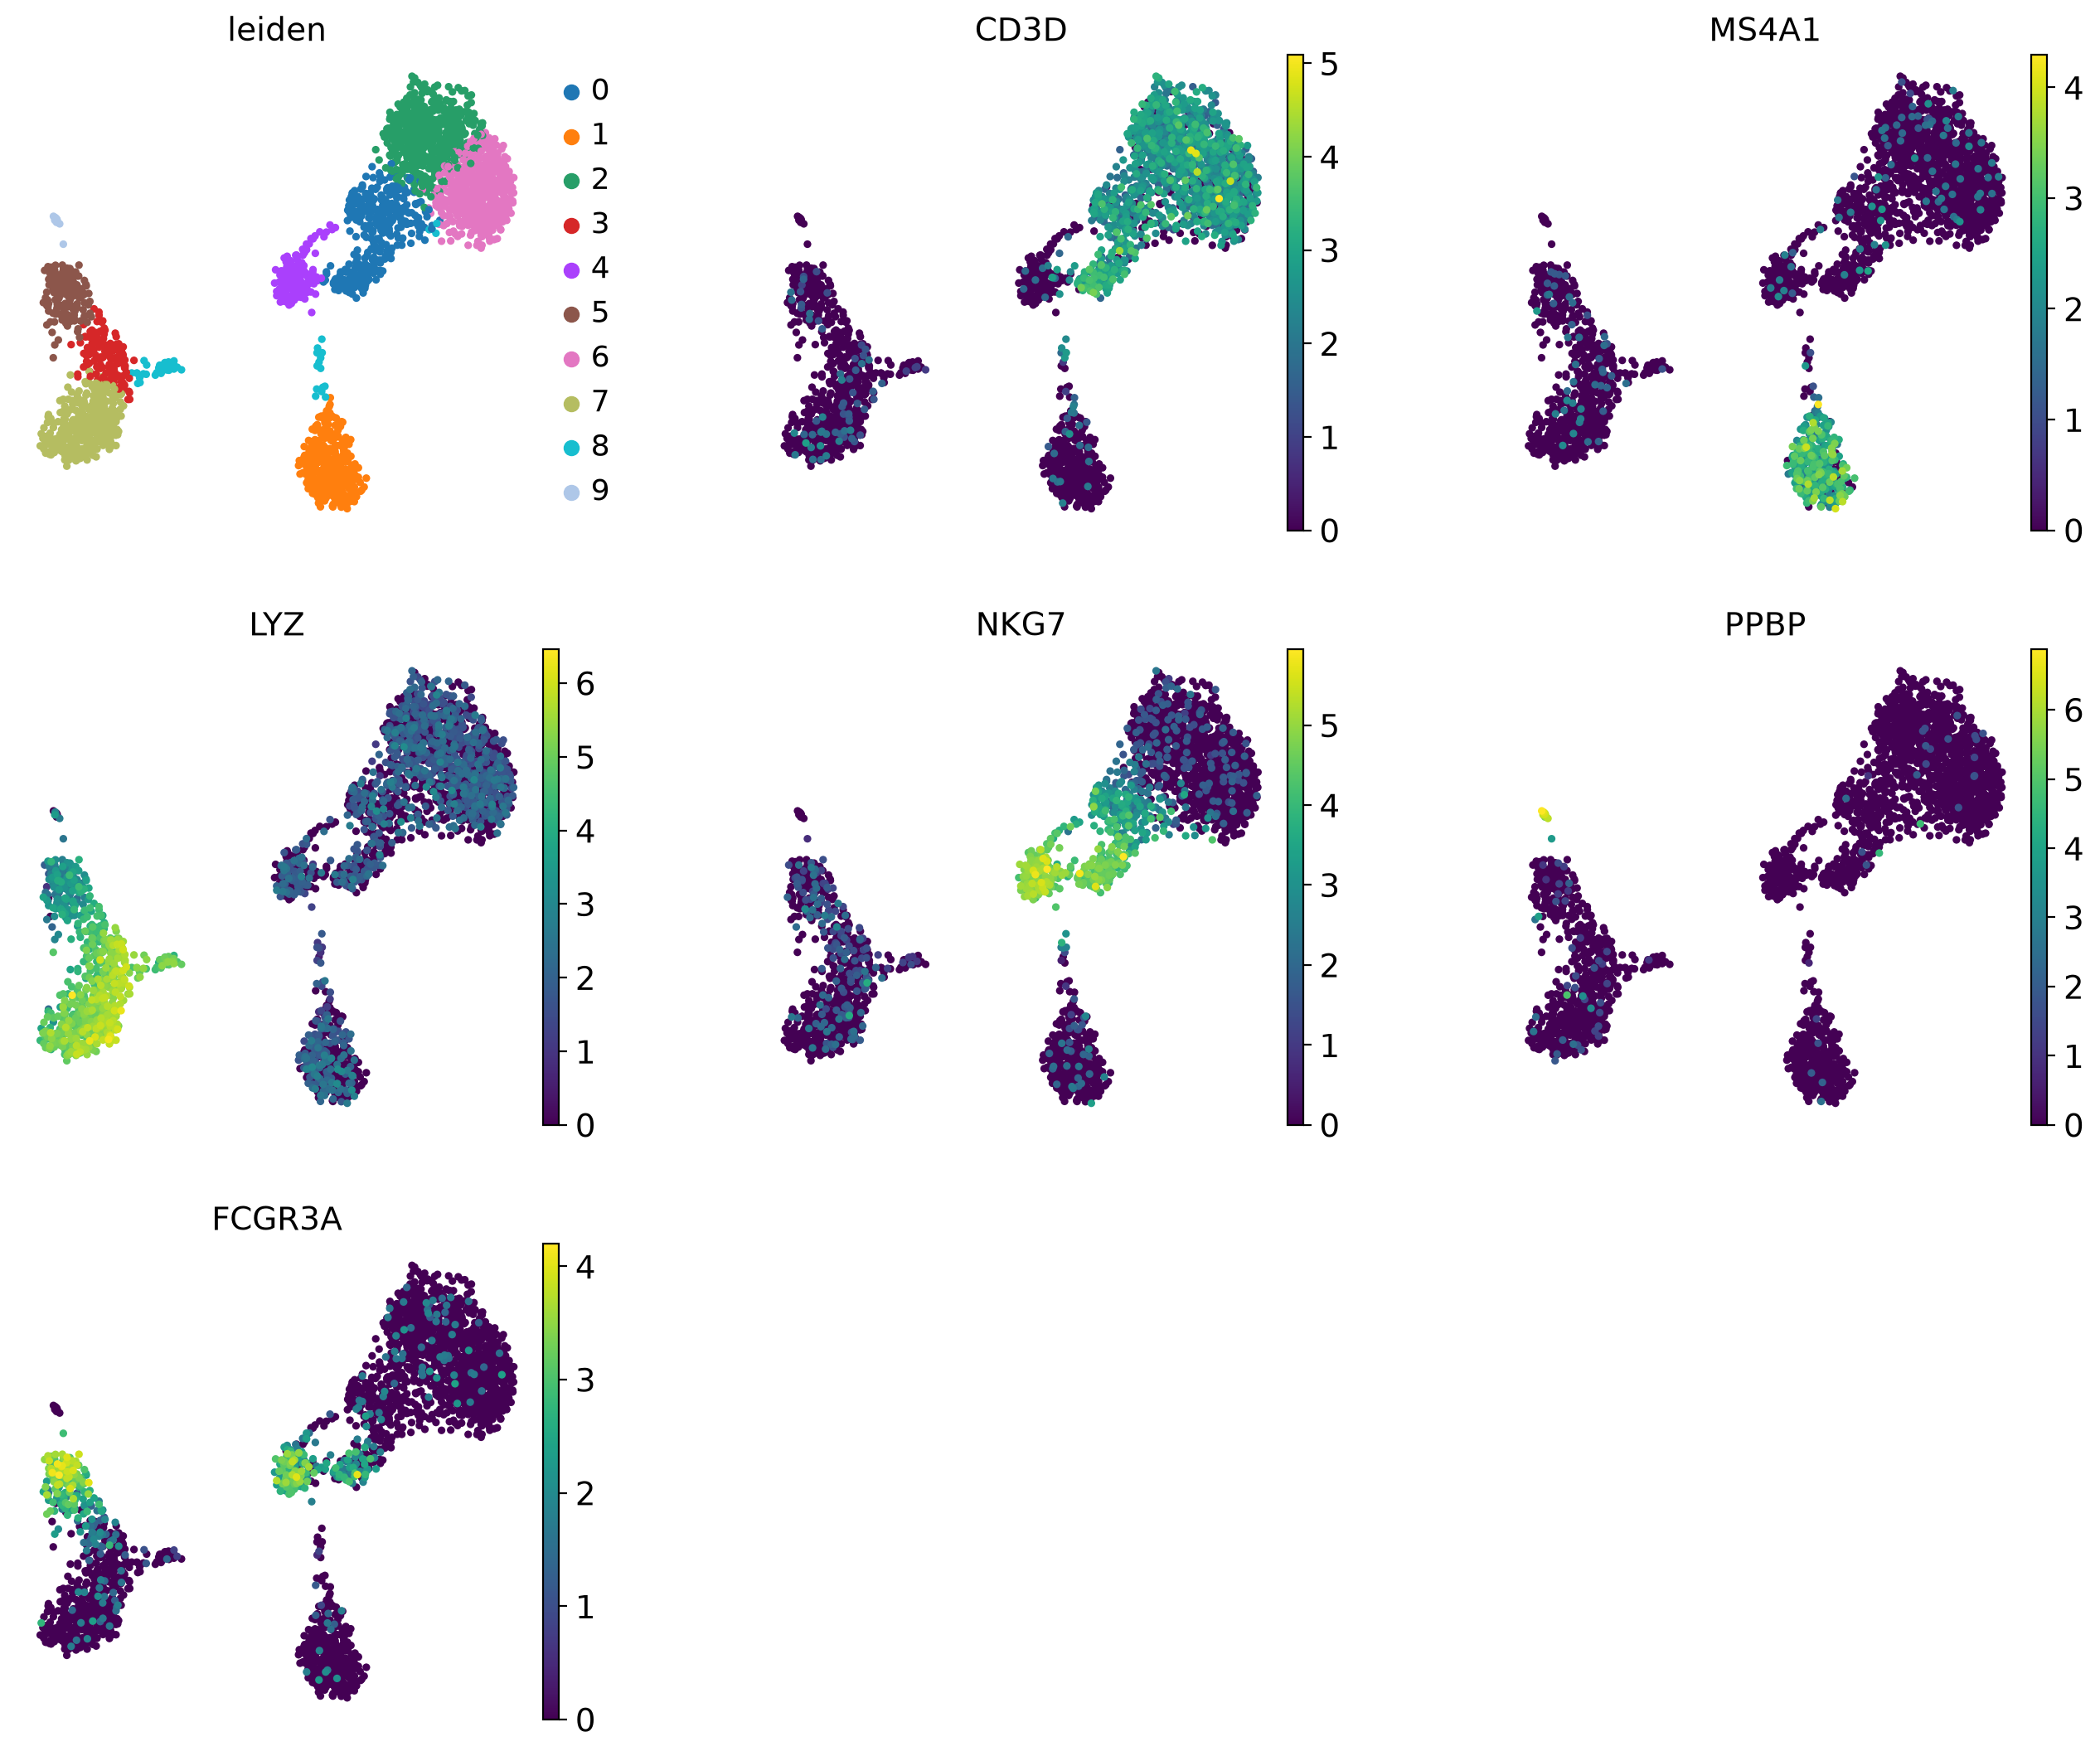

In [7]:
markers = [m for m in ["CD3D", "MS4A1", "LYZ", "NKG7", "PPBP", "FCGR3A"] if m in adata.var_names]
sc.pl.umap(adata, color=["leiden", *markers], ncols=3, wspace=0.3)


Clusters separate along the expected lineage markers (T cells / `CD3D`,
B cells / `MS4A1`, monocytes / `LYZ`, NK cells / `NKG7`, platelets / `PPBP`,
FCGR3A⁺ monocytes) with no gold labels involved — this is the sanity check
you would run on your own data before trusting a clustering.


## 5. When should you change the defaults?

Most calls should start from `scf.pp.highly_variable_genes(adata)` with no
extra arguments — that is **auto `n` + append**, covering both product goals:

| Goal | Default | When to override |
|------|---------|------------------|
| Choose list size (`n`) | `n_top_genes="auto"` | Paper / locked protocol → fixed int (e.g. `2000`) |
| Fairer allocation | `balance_method="append"` | Exact scanpy match → `balance_method="none"` |

Reach for other knobs only when you have a specific reason (table below).


| Situation | Do this |
|---|---|
| Need output that matches plain scanpy HVG exactly (e.g. reproducing a published protocol) | `n_top_genes=2000, balance_method="none"` |
| Fixed classical budget, keep append | `n_top_genes=2000` (skip auto, still append) |
| A specific gene set must appear in the output regardless of ranking (a fixed panel, a known lineage marker) | `marker_genes=[...]` |
| Already have coarse cell-type / sample labels | Call {func}`scfair.pp.diagnose_from_labels` *before* choosing a method |
| Suspect a rare population is losing markers to the append/none path | Force its known markers with `marker_genes=[...]` (below), or try `mode="fine"` |

Two of these, run on the data above:


In [8]:
# 1) exact scanpy match
adata_none = sc.datasets.pbmc3k()
adata_none.var_names_make_unique()
sc.pp.filter_cells(adata_none, min_genes=200)
sc.pp.filter_genes(adata_none, min_cells=3)
scf.pp.highly_variable_genes(adata_none, n_top_genes=2000, balance_method="none")
print("none:", int(adata_none.var["highly_variable"].sum()), "genes (fixed 2000, no append)")

# 2) force in markers the default path dropped
adata_markers = sc.datasets.pbmc3k()
adata_markers.var_names_make_unique()
sc.pp.filter_cells(adata_markers, min_genes=200)
sc.pp.filter_genes(adata_markers, min_cells=3)
scf.pp.highly_variable_genes(adata_markers, marker_genes=["CD3D", "CD8A"])
sel = adata_markers.var.loc[["CD3D", "CD8A"], "highly_variable"]
print("forced markers selected:\n", sel)


config: balance_method='none': global HVG only (same idea as scanpy).


diagnosis: This setup usually matches plain scanpy HVG — balance_method='none' is enough.


none: 2000 genes (fixed 2000, no append)


forced markers selected:
 index
CD3D    True
CD8A    True
Name: highly_variable, dtype: bool


`CD3D` and `CD8A` were *not* in the default 2,200-gene list picked above (they
rank below the cutoff on this dataset) but are guaranteed present once passed
as `marker_genes` (`marker_mode="force"`, the default when `marker_genes` is
given). They are added *on top of* the base list — see
{doc}`../faq` for the `marker_extra` knob that controls whether forced
markers extend the list or fold into its budget instead.


## Next

- Defaults and every parameter: {doc}`../user_guide/method`, {doc}`../user_guide/parameters`
- Full signatures: {doc}`../api/index`
- Common questions: {doc}`../faq`
- Method comparison against gold labels: {doc}`pbmc10k_hvg_compare`
